# Quantum Diabetes Prediction on PIMA (PennyLane Prototype)

This notebook is a **reproducible prototype** for binary classification on the **Pima Indians Diabetes** dataset using a **Variational Quantum Classifier (VQC)** in **PennyLane**.

It includes:
- Dataset download using **kagglehub** (as requested)
- Preprocessing (imputation, scaling, PCA-to-qubits)
- A PennyLane **VQC** (AngleEmbedding + hardware-efficient ansatz)
- Evaluation (accuracy, ROC/PR curves, confusion matrix)
- **Threshold tuning**
- A classical baseline (Logistic Regression)

> Notes:
> - KaggleHub may require you to be logged in / configured to access Kaggle datasets.
> - If KaggleHub fails, the notebook provides a fallback option.


* **03 VQC Prototype Noise-free**:
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Megaantony00/qml-diabetes-nisq/blob/main/notebooks/03_vqc_prototype_noisefree.ipynb)

In [ ]:
import sys
import os

if 'google.colab' in sys.modules:
    !pip install -q pennylane>=0.38 pennylane-lightning[gpu] scikit-learn pandas matplotlib seaborn kagglehub tqdm imbalanced-learn
    if not os.path.exists('results'): os.makedirs('results')
    print("Environment configured for Colab.")
else:
    print("Environment configured for Local/Server usage.")

Note: you may need to restart the kernel to use updated packages.


## 1) Imports

In [2]:
import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)
from sklearn.linear_model import LogisticRegression

import pennylane as qml
from tqdm.auto import tqdm

np.random.seed(42)

In [3]:
import os
import pennylane as qml

# 1. CONFIGURAZIONE QUBIT E NOME CARTELLA
n_qubits = 8  # Cambia a 8 per la seconda run
n_components = n_qubits
n_layers = 2

save_folder = "Tesi_Risultati_VQC"
os.makedirs(save_folder, exist_ok=True)
print(f"I risultati verranno salvati in: {save_folder}")

I risultati verranno salvati in: Tesi_Risultati_VQC


## 2) Download dataset (KaggleHub)

In [4]:
import kagglehub

# Download latest version (as provided)
path = kagglehub.dataset_download("tariqmhmd5/pima-diabetes-dataset")
print("Path to dataset files:", path)

# Try to find a CSV inside the downloaded folder
csv_candidates = glob.glob(str(Path(path) / "**" / "*.csv"), recursive=True)
print("CSV candidates:", csv_candidates)

if not csv_candidates:
    raise FileNotFoundError("No CSV file found in the KaggleHub dataset folder. Inspect 'path' manually.")
csv_path = csv_candidates[0]
print("Using:", csv_path)

Path to dataset files: /home/habes/.cache/kagglehub/datasets/tariqmhmd5/pima-diabetes-dataset/versions/1
CSV candidates: ['/home/habes/.cache/kagglehub/datasets/tariqmhmd5/pima-diabetes-dataset/versions/1/Diabetes.csv']
Using: /home/habes/.cache/kagglehub/datasets/tariqmhmd5/pima-diabetes-dataset/versions/1/Diabetes.csv


## 3) Load + quick look

In [5]:
df = pd.read_csv(csv_path)
display(df.head())
print("Shape:", df.shape)
print(df.dtypes)
print(df['Outcome'].value_counts() if 'Outcome' in df.columns else "No 'Outcome' column found")

,Number of times pregnant,Plasma glucose concentration,Diastolic blood pressure,Triceps skin fold thickness,2-Hour serum insulin,Body mass index,Diabetes pedigree function,Age (years),Class variable
0,6,148,72,35,0,33.6,0.627,50,YES
1,1,85,66,29,0,26.6,0.351,31,NO
2,8,183,64,0,0,23.3,0.672,32,YES
3,1,89,66,23,94,28.1,0.167,21,NO
4,0,137,40,35,168,43.1,2.288,33,YES


Shape: (768, 9)
Number of times pregnant          int64
Plasma glucose concentration      int64
Diastolic blood pressure          int64
Triceps skin fold thickness       int64
2-Hour serum insulin              int64
Body mass index                 float64
Diabetes pedigree function      float64
Age (years)                       int64
Class variable                   object
dtype: object
No 'Outcome' column found


## 4) Preprocessing

Typical PIMA quirks:
- Some physiological columns contain zeros that actually mean *missing* (common practice is to treat them as missing).
- We'll replace zeros with NaN for selected columns, impute with median, then scale features.

Then we reduce dimensionality to match the number of qubits via **PCA** (a pragmatic NISQ-friendly step).


In [6]:
# --- CELLA 4 INTEGRATA (CORRETTA) ---

# 1. Identificazione colonna label e mappatura YES/NO
label_col = "Class variable" if "Class variable" in df.columns else (
    "Outcome" if "Outcome" in df.columns else df.columns[-1]
)
print("Label column identificata:", label_col)

# Feature columns
feature_cols = [c for c in df.columns if c != label_col]
X = df[feature_cols].copy()

# FIX ERRORE: Trasformiamo le stringhe 'YES'/'NO' in numeri interi
y = df[label_col].map({
    'YES': 1, 'NO': 0,
    'positive': 1, 'negative': 0,
    '1': 1, '0': 0,
    1: 1, 0: 0
}).astype(int).values

# 2. Gestione degli zeri come valori mancanti (Standard PIMA)
zero_as_missing = [c for c in ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"] if c in X.columns]
print("Treating zeros as missing in:", zero_as_missing)
X[zero_as_missing] = X[zero_as_missing].replace(0, np.nan)

# 3. Divisione Train/Test (Stratificata)
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.25, random_state=42, stratify=y
)

# 4. Imputazione + Scaling (Necessari per il VQC)
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

print("✅ Preprocessing completato.")
print("Train shape:", X_train_scaled.shape, "Test shape:", X_test_scaled.shape)

Label column identificata:  Class variable
Treating zeros as missing in: []
✅ Preprocessing completato.
Train shape: (576, 8) Test shape: (192, 8)


### Choose number of qubits (PCA → qubits)
We’ll start with **4 qubits** (good tradeoff for a small dataset). You can try 2–6.

In [7]:
#n_qubits = 4

pca = PCA(n_components=n_components, random_state=42)
X_train_q = pca.fit_transform(X_train_scaled)
X_test_q = pca.transform(X_test_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Sum explained variance:", pca.explained_variance_ratio_.sum())

# Optional: scale PCA outputs into a reasonable range for rotation angles
# We'll map each feature to [-pi, pi] using a robust scaling based on training quantiles.
q_low, q_high = np.quantile(X_train_q, 0.05, axis=0), np.quantile(X_train_q, 0.95, axis=0)

def to_angles(X):
    Xc = np.clip(X, q_low, q_high)
    # normalize to [0,1]
    Xn = (Xc - q_low) / (q_high - q_low + 1e-9)
    # map to [-pi, pi]
    return (Xn * 2 - 1) * np.pi

X_train_ang = to_angles(X_train_q)
X_test_ang = to_angles(X_test_q)

print("Angle features range (train):", X_train_ang.min(), X_train_ang.max())

Explained variance ratio: [0.2587334  0.21608225 0.13172228 0.10518003 0.09884707 0.08674359
 0.05628148 0.04640991]
Sum explained variance: 1.0
Angle features range (train): -3.141592653589793 3.141592652220357


## 5) PennyLane Variational Quantum Classifier (VQC)

**Circuit design**
- **AngleEmbedding** of PCA-reduced features onto qubits
- A small hardware-efficient ansatz (Rot + ring entanglement)
- Measure ⟨Z₀⟩ and map to probability with sigmoid (or linear map)

We train by minimizing **binary cross entropy**.


In [8]:
import pennylane as qml
import pennylane.numpy as pnp # Importante: deve stare in alto

# --- 1. CONFIGURAZIONE DEVICE CPU CON RUMORE ---
dev_base = qml.device("default.mixed", wires=n_qubits)

# --- 2. MODELLO DI RUMORE ---
# I template di PennyLane si scompongono in Rot, RX, RY, RZ e CNOT. Li intercettiamo tutti.
fcond = qml.noise.op_in([qml.RX, qml.RY, qml.RZ, qml.Rot, qml.Hadamard])
noise_after_rot = qml.noise.partial_wires(qml.DepolarizingChannel, 0.01)

meas_cond = qml.noise.meas_eq(qml.expval)
readout_noise = qml.noise.partial_wires(qml.PhaseFlip, 0.02)

noise_model = qml.NoiseModel(
    {fcond: noise_after_rot},
    {meas_cond: readout_noise}
)

# IL FIX È QUI: In PennyLane 0.42 il rumore si applica al device, non come decoratore!
dev_noisy = qml.add_noise(dev_base, noise_model)

# --- 3. QNODE RUMOROSO ---
@qml.qnode(dev_noisy, interface="autograd")
def circuit(features, weights):
    # 1. Caricamento dati
    qml.AngleEmbedding(features, wires=range(n_qubits))

    # 2. Strati addestrabili (Template PennyLane ottimizzato)
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))

    return qml.expval(qml.PauliZ(0))

# --- 4. FUNZIONI DI SUPPORTO ---
def predict_proba(X, weights):
    # Usiamo pnp.stack e pnp.exp per non perdere i gradienti
    logits = pnp.stack([circuit(x, weights) for x in X])
    return 1 / (1 + pnp.exp(-logits))

def binary_cross_entropy(y_true, p_pred, eps=1e-9):
    p_pred = pnp.clip(p_pred, eps, 1 - eps)
    return -pnp.mean(y_true * pnp.log(p_pred) + (1 - y_true) * pnp.log(1 - p_pred))

def cost(weights, Xb, yb):
    p = predict_proba(Xb, weights)
    return binary_cross_entropy(yb, p)

# --- INIZIALIZZAZIONE ---
# Reinizializzazione corretta con pnp
weights = pnp.array(0.01 * pnp.random.randn(n_layers, n_qubits, 3), requires_grad=True)

# Reimposta l'ottimizzatore
opt = qml.optimize.AdamOptimizer(stepsize=0.05)

print(f"✅ Modello e ottimizzatore pronti per {n_qubits} Qubits su CPU (con Rumore).")

✅ Modello e ottimizzatore pronti per 8 Qubits su CPU (con Rumore).


### Training loop

In [9]:
import pickle
import pandas as pd
import os
from tqdm.auto import tqdm
import numpy as np

epochs = 120
batch_size = 48

Xtr, ytr = X_train_ang, y_train
Xte, yte = X_test_ang, y_test

# CORREZIONE: Usiamo "val_loss" invece di "loss"
history = {"val_loss": [], "val_auc": [], "val_acc": []}

# Percorsi dei file
file_pesi = os.path.join(save_folder, "best_weights_vqc.pkl")
file_history = os.path.join(save_folder, "training_history_vqc.csv")

# 1. LOGICA DI RECUPERO ROBUSTA
if os.path.exists(file_pesi) and os.path.getsize(file_pesi) > 0:
    try:
        with open(file_pesi, "rb") as f:
            weights = pickle.load(f)
        
        # Se i pesi sono caricati, proviamo a caricare la cronologia
        if os.path.exists(file_history):
            history = pd.read_csv(file_history).to_dict(orient="list")
            start_epoch = len(history["val_loss"]) + 1
            print(f"✅ Recupero riuscito! Ripartiamo dall'epoca {start_epoch}")
        else:
            print("⚠️ Pesi trovati ma cronologia mancante. Reinizializzo history.")
            history = {"val_loss": [], "val_auc": [], "val_acc": []}
            start_epoch = 1
            
    except (EOFError, pickle.UnpicklingError):
        print("❌ Il file dei pesi è corrotto (vuoto). Lo ignoro e riparto da zero.")
        weights = pnp.array(0.01 * pnp.random.randn(n_layers, n_qubits, 3), requires_grad=True)
        history = {"val_loss": [], "val_auc": [], "val_acc": []}
        start_epoch = 1
else:
    # Se il file non esiste o è di 0 bytes
    print("🆕 Nessun salvataggio precedente trovato. Inizio nuovo addestramento...")
    weights = pnp.array(0.01 * pnp.random.randn(n_layers, n_qubits, 3), requires_grad=True)
    history = {"val_loss": [], "val_auc": [], "val_acc": []}
    start_epoch = 1

# Ora il loop for epoch in range(start_epoch, 121) può girare tranquillo

opt = qml.optimize.AdamOptimizer(stepsize=0.05)

for epoch in tqdm(range(start_epoch, epochs + 1)):
    idx = np.random.permutation(len(Xtr))
    Xs, ys = Xtr[idx], ytr[idx]

    for start in range(0, len(Xs), batch_size):
        Xb = Xs[start:start + batch_size]
        yb = ys[start:start + batch_size]
        weights = opt.step(lambda w: cost(w, Xb, yb), weights)

    # CORREZIONE: Valutazione sui dati giusti (Xte, yte)
    p_val = np.asarray(predict_proba(Xte, weights), dtype=float)
    val_auc = roc_auc_score(yte, p_val)
    val_acc = accuracy_score(yte, (p_val >= 0.5).astype(int))
    val_loss = float(binary_cross_entropy(yte, p_val))

    history["val_loss"].append(val_loss)
    history["val_auc"].append(val_auc)
    history["val_acc"].append(val_acc)

    # Salvataggio progressivo
    pd.DataFrame(history).to_csv(file_history, index=False)
    with open(file_pesi, "wb") as f:
        pickle.dump(weights, f)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | val_loss={val_loss:.4f} | val_auc={val_auc:.4f} | val_acc={val_acc:.4f}")

🆕 Nessun salvataggio precedente trovato. Inizio nuovo addestramento...


  0%|          | 0/120 [00:00<?, ?it/s]

Epoch 001 | val_loss=0.6975 | val_auc=0.4362 | val_acc=0.5000
Epoch 005 | val_loss=0.6990 | val_auc=0.4832 | val_acc=0.5208
Epoch 010 | val_loss=0.6938 | val_auc=0.5189 | val_acc=0.5417
Epoch 015 | val_loss=0.6936 | val_auc=0.5147 | val_acc=0.5104
Epoch 020 | val_loss=0.6931 | val_auc=0.5174 | val_acc=0.5052
Epoch 025 | val_loss=0.6920 | val_auc=0.5210 | val_acc=0.4948
Epoch 030 | val_loss=0.6929 | val_auc=0.5125 | val_acc=0.5104
Epoch 035 | val_loss=0.6925 | val_auc=0.5179 | val_acc=0.4948
Epoch 040 | val_loss=0.6924 | val_auc=0.5116 | val_acc=0.4792
Epoch 045 | val_loss=0.6922 | val_auc=0.5144 | val_acc=0.4844
Epoch 050 | val_loss=0.6930 | val_auc=0.5076 | val_acc=0.4896
Epoch 055 | val_loss=0.6933 | val_auc=0.5060 | val_acc=0.4792
Epoch 060 | val_loss=0.6930 | val_auc=0.5113 | val_acc=0.5000
Epoch 065 | val_loss=0.6929 | val_auc=0.5102 | val_acc=0.4792
Epoch 070 | val_loss=0.6920 | val_auc=0.5121 | val_acc=0.4792
Epoch 075 | val_loss=0.6934 | val_auc=0.5106 | val_acc=0.4844
Epoch 08

### Learning curves

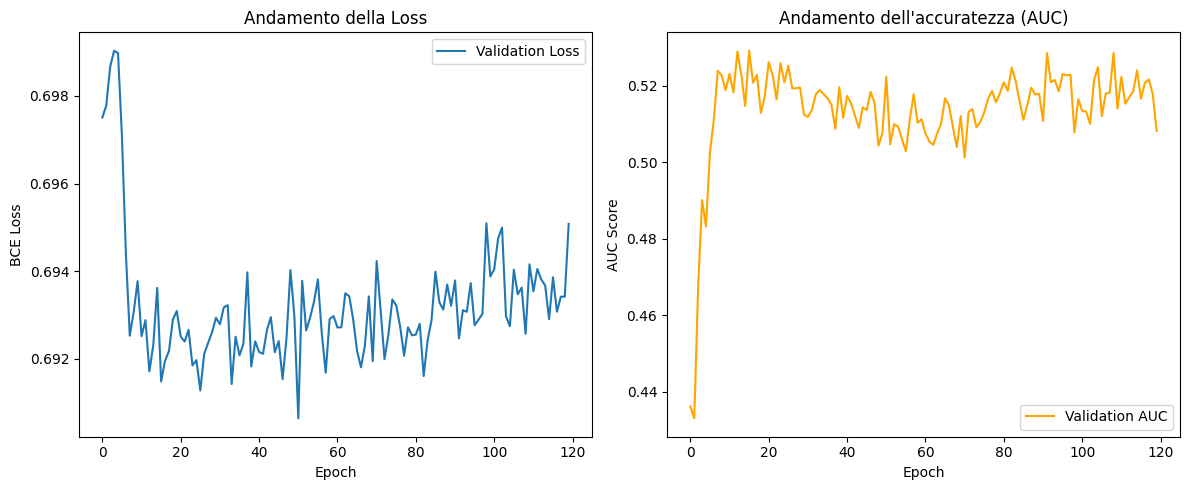

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Grafico della Loss
plt.subplot(1, 2, 1)
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Andamento della Loss")
plt.legend()

# Grafico dell'AUC
plt.subplot(1, 2, 2)
plt.plot(history["val_auc"], label="Validation AUC", color="orange")
plt.xlabel("Epoch")
plt.ylabel("AUC Score")
plt.title("Andamento dell'accuratezza (AUC)")
plt.legend()

plt.tight_layout()
# Salviamo il grafico per la tesi
plt.savefig(os.path.join(save_folder, "final_training_curves.png"), dpi=300)
plt.show()

## 6) Evaluation: ROC/PR, confusion matrix, threshold tuning

Test ROC AUC: 0.5081791044776119
Test Average Precision (PR AUC): 0.3819150811143803


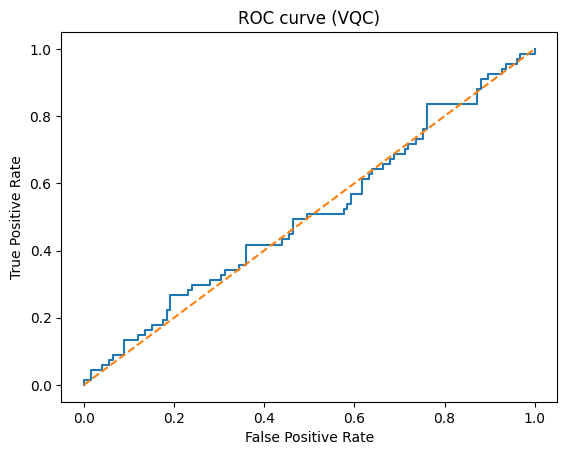

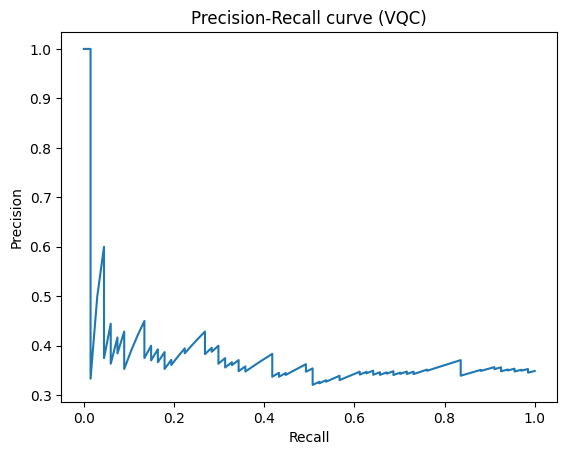

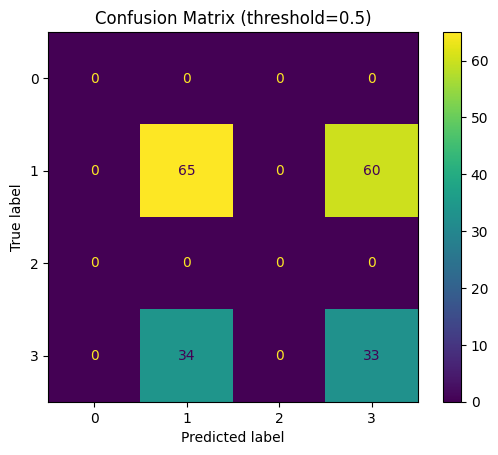

Accuracy (0.5): 0.5104166666666666
F1 (0.5): 0.4125
Best threshold (by F1): 0.05 Best F1: 0.5173745173745173 Acc: 0.3489583333333333


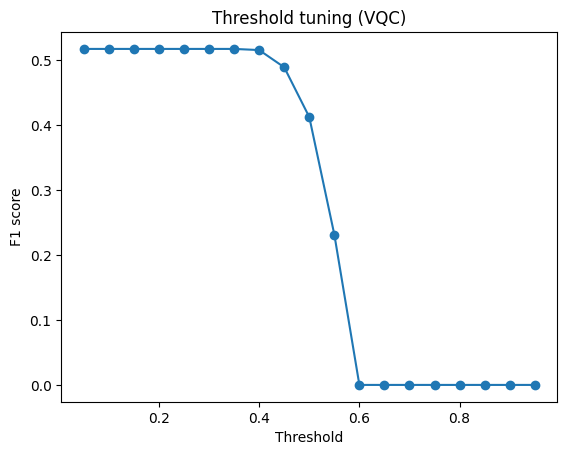

In [12]:
# --- CELLA 20: VALUTAZIONE E SALVATAGGIO GRAFICI ---
import os

p_test = predict_proba(Xte, weights)
auc = roc_auc_score(yte, p_test)
ap = average_precision_score(yte, p_test)
print("Test ROC AUC:", auc)
print("Test Average Precision (PR AUC):", ap)

# 1. Salva ROC curve
fpr, tpr, thr = roc_curve(yte, p_test)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve (VQC)")
plt.savefig(os.path.join(save_folder, "ROC_curve_VQC.png"), dpi=300)
plt.show()

# 2. Salva PR curve
prec, rec, thr_pr = precision_recall_curve(yte, p_test)
plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curve (VQC)")
plt.savefig(os.path.join(save_folder, "PR_curve_VQC.png"), dpi=300)
plt.show()

# 3. Salva Confusion Matrix
y_pred_05 = (p_test >= 0.5).astype(int)
cm = confusion_matrix(yte, y_pred_05)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Confusion Matrix (threshold=0.5)")
plt.savefig(os.path.join(save_folder, "Confusion_Matrix_VQC.png"), dpi=300)
plt.show()

print("Accuracy (0.5):", accuracy_score(yte, y_pred_05))
print("F1 (0.5):", f1_score(yte, y_pred_05))

# 4. Salva grafico Threshold tuning
thresholds = np.linspace(0.05, 0.95, 19)
f1s = []
accs = []
for t in thresholds:
    yp = (p_test >= t).astype(int)
    f1s.append(f1_score(yte, yp))
    accs.append(accuracy_score(yte, yp))

best_i = int(np.argmax(f1s))
best_t = thresholds[best_i]
print("Best threshold (by F1):", best_t, "Best F1:", f1s[best_i], "Acc:", accs[best_i])

plt.figure()
plt.plot(thresholds, f1s, marker="o")
plt.xlabel("Threshold")
plt.ylabel("F1 score")
plt.title("Threshold tuning (VQC)")
plt.savefig(os.path.join(save_folder, "Threshold_Tuning_VQC.png"), dpi=300)
plt.show()

## 7) Classical baseline (Logistic Regression)

In [13]:
# Use the same preprocessing but without PCA-to-angles; just use scaled features.
clf = LogisticRegression(max_iter=2000, class_weight="balanced")
clf.fit(X_train_scaled, y_train)
p_lr = clf.predict_proba(X_test_scaled)[:, 1]

auc_lr = roc_auc_score(y_test, p_lr)
acc_lr = accuracy_score(y_test, (p_lr >= 0.5).astype(int))
ap_lr = average_precision_score(y_test, p_lr)

print("LogReg ROC AUC:", auc_lr)
print("LogReg AP (PR AUC):", ap_lr)
print("LogReg Accuracy:", acc_lr)

LogReg ROC AUC: 0.8329552238805971
LogReg AP (PR AUC): 0.7173014414794692
LogReg Accuracy: 0.7604166666666666


## 8) (Optional) Quantum Kernel SVM (QSVM-style) in PennyLane

Quantum kernels require building an \(N \times N\) kernel matrix (O(N²)).
For PIMA (768 samples) it's feasible but can be slow; you can subsample.

This is **optional**—the VQC above is the main prototype.


In [ ]:
# OPTIONAL: uncomment to run (can be slow for full training set).
# from sklearn.svm import SVC
#
# # Subsample for speed (edit as you like)
# n_train_sub = 300
# n_test_sub = 200
# Xk_train = X_train_ang[:n_train_sub]
# yk_train = y_train[:n_train_sub]
# Xk_test = X_test_ang[:n_test_sub]
# yk_test = y_test[:n_test_sub]
#
# # Define a feature map circuit for kernel evaluation
# dev_k = qml.device("default.qubit", wires=n_qubits, shots=None)
#
# @qml.qnode(dev_k, interface="autograd")
# def feature_map(x):
#     qml.AngleEmbedding(x, wires=range(n_qubits), rotation="Y")
#     for i in range(n_qubits):
#         qml.CNOT(wires=[i, (i+1) % n_qubits])
#     return qml.state()
#
# def kernel(x1, x2):
#     # Fidelity between states |phi(x1)> and |phi(x2)>
#     s1 = feature_map(x1)
#     s2 = feature_map(x2)
#     return np.abs(np.vdot(s1, s2))**2
#
# def kernel_matrix(A, B):
#     K = np.zeros((len(A), len(B)))
#     for i in range(len(A)):
#         for j in range(len(B)):
#             K[i, j] = kernel(A[i], B[j])
#     return K
#
# K_train = kernel_matrix(Xk_train, Xk_train)
# K_test = kernel_matrix(Xk_test, Xk_train)
#
# svc = SVC(kernel="precomputed", class_weight="balanced")
# svc.fit(K_train, yk_train)
# pred = svc.predict(K_test)
# acc = accuracy_score(yk_test, pred)
# print("Quantum Kernel SVM Accuracy (subsample):", acc)

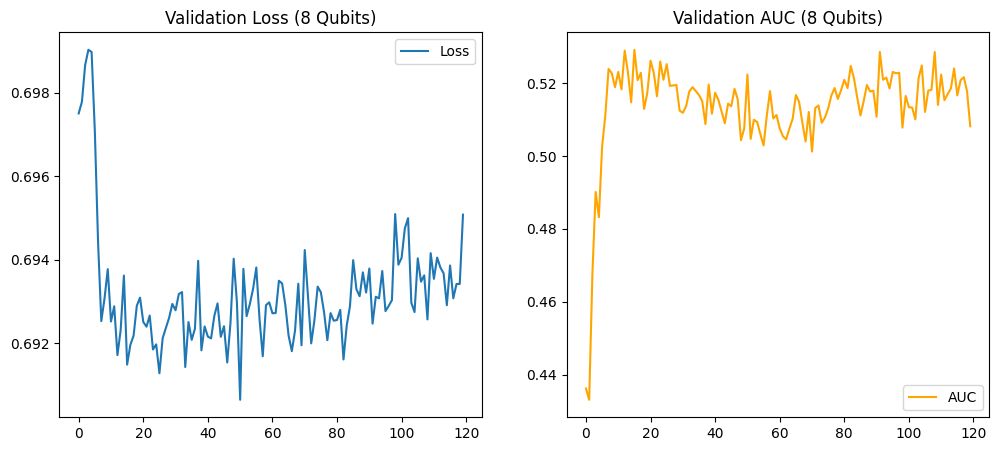

✅ Tutto salvato in sicurezza! Controlla i tuoi PNG e CSV nella cartella: Tesi_Risultati_VQC


In [14]:
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt

# 1. USA IL PERCORSO DINAMICO LOCALE
if not os.path.exists(save_folder): os.makedirs(save_folder)

# 2. Salva la cronologia (Loss, AUC, Acc) in un CSV
df_hist = pd.DataFrame(history)
df_hist.to_csv(os.path.join(save_folder, "vqc_prototype_history.csv"), index=False)

# 3. Salva le metriche finali e il confronto
final_metrics = {
    "vqc_auc": auc,
    "vqc_ap": ap,
    "logreg_auc": auc_lr,
    "n_layers": n_layers,
    "n_qubits": n_qubits
}

with open(os.path.join(save_folder, "vqc_prototype_metrics.pkl"), "wb") as f:
    pickle.dump(final_metrics, f)

# 4. Salva i grafici riassuntivi (CORRETTO NOME val_loss)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history["val_loss"], label="Loss")
plt.title(f"Validation Loss ({n_qubits} Qubits)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["val_auc"], label="AUC", color="orange")
plt.title(f"Validation AUC ({n_qubits} Qubits)")
plt.legend()

plt.savefig(os.path.join(save_folder, "learning_curves_vqc.png"), dpi=300)
plt.show()

print(f"✅ Tutto salvato in sicurezza! Controlla i tuoi PNG e CSV nella cartella: {save_folder}")